---
### Imports
---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
### Loading Datasets
---

In [7]:
# Configure plots
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

In [8]:
# Load dataset
df = pd.read_csv("../data/raw/california_housing.csv")

---
### Basic Exploration
---

In [4]:
# Quick inspection
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
# Summary statistics
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
# Check missing values
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

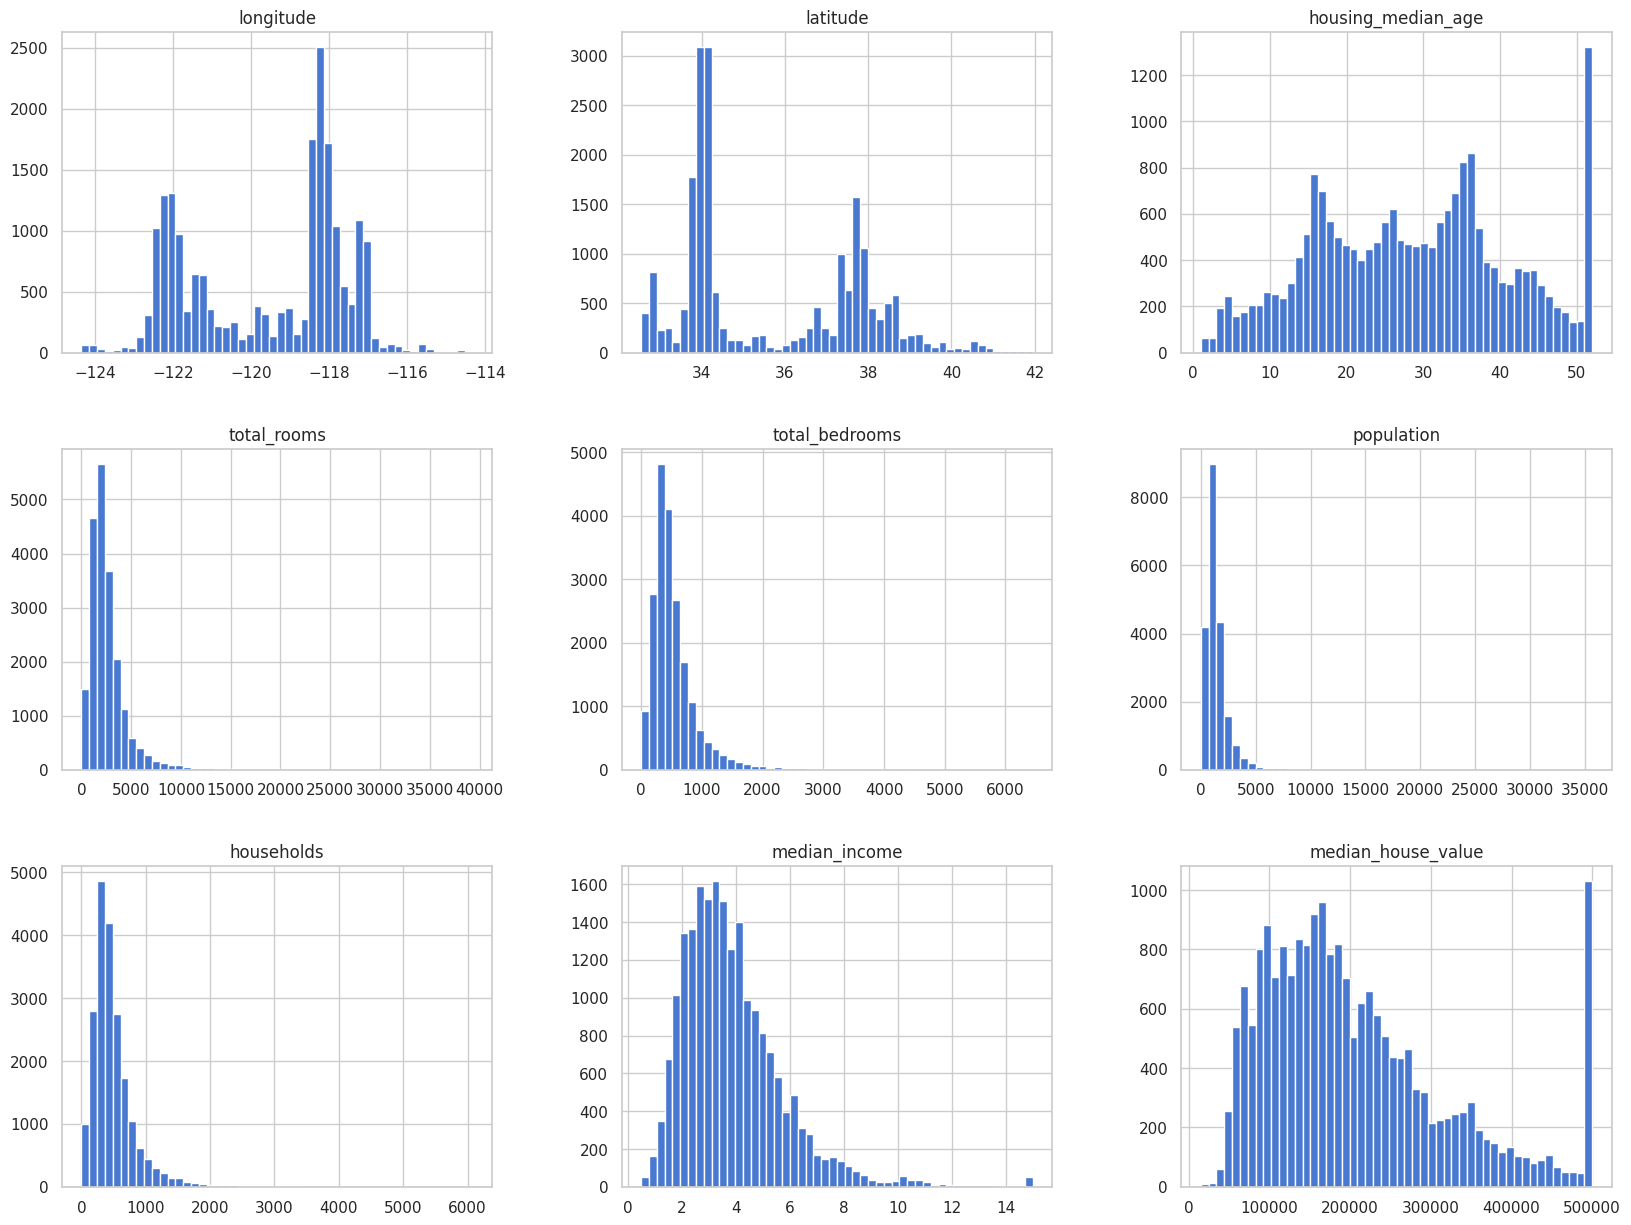

In [11]:
# Dataset at a glance
df.hist(bins=50, figsize=(20,15))
plt.show()

---
### Visualizations 
---

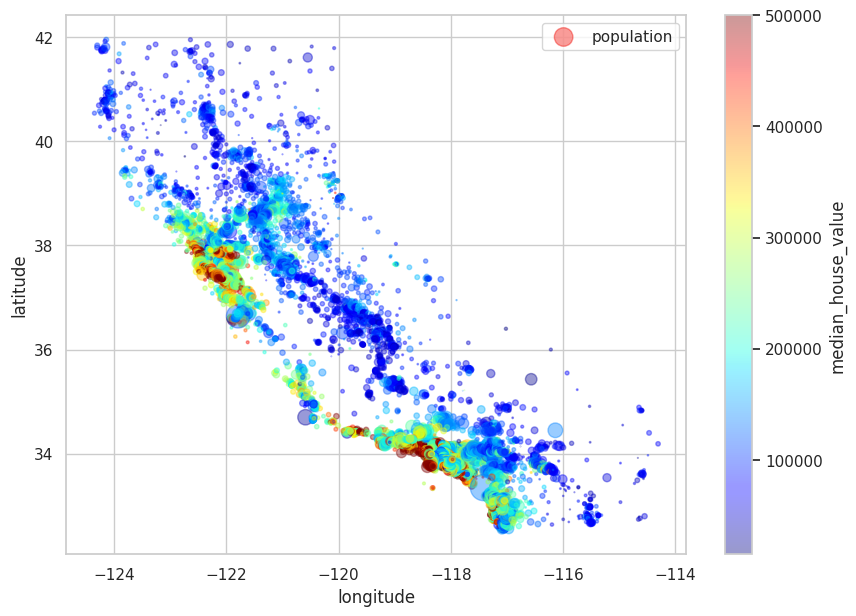

In [12]:
# Plot 01  -> Population density and Housing value across California
# Color shows house value.
# Size shows population density.

df.plot(
    kind="scatter", 
    x="longitude", 
    y="latitude", 
    alpha=0.4, 
    s=df["population"]/100, 
    label="population", 
    c="median_house_value",
    colormap="jet", 
    colorbar=True, 
    figsize=(10,7)
)
plt.legend()
plt.show()

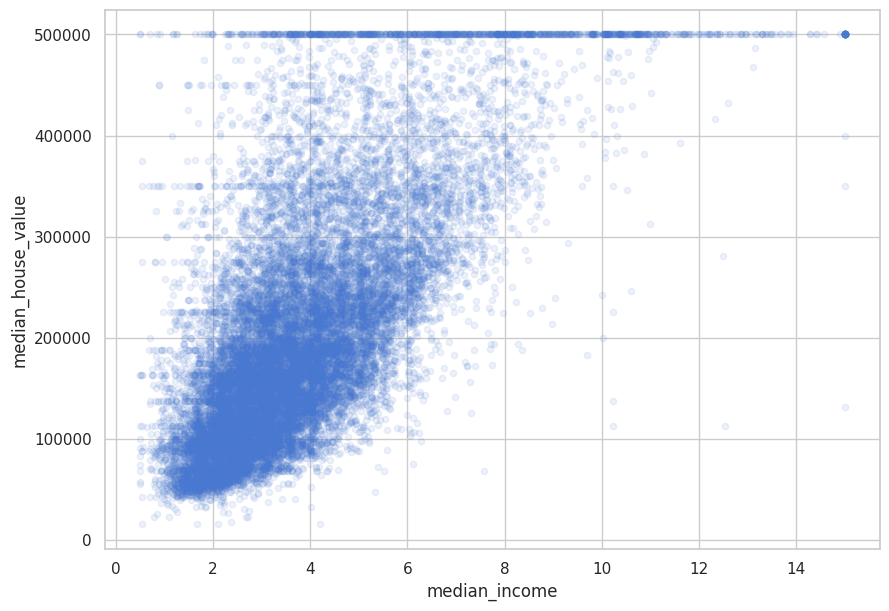

In [13]:
# Plot 02 -> Median income vs Median house value

df.plot(
    kind="scatter", 
    x="median_income", 
    y="median_house_value", 
    alpha=0.1, 
    figsize=(10,7)
)
plt.show()

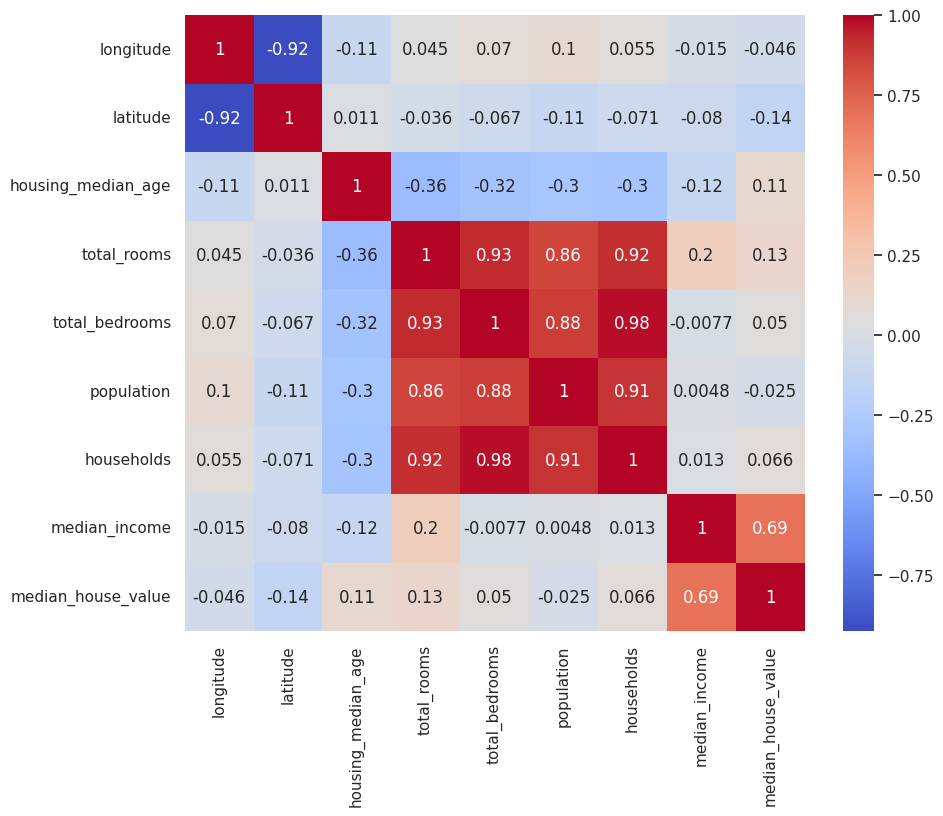

In [ ]:
# Plot 03 -> Correlation Heatmap

corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm"
)
-plt.show()

---
### Takeaways:
- Missing Values in the column 'total_bedrooms'.
- Categorical Variable -> ocean_proximity.
- Median house value is capped at $500,000 (Plot 02).
- Median income shows the strongest correlation with house value (Plot 03).
- High-value housing clusters are cincentrated near Los Angeles and San Francisco.
---